In [1]:
# Install required libraries for deep learning, pretrained vision models, image processing, and visualization
!pip install torch torchvision opencv-python matplotlib

In [2]:
# Import libraries for deep learning (PyTorch), pretrained detection models (TorchVision), image processing (OpenCV), numerical operations (NumPy), and visualization (Matplotlib)
import torch
import torchvision
from torchvision.transforms import functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load a pretrained Faster R-CNN model for object detection and move it to GPU if available
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 56.0MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [4]:
# Define class labels from the COCO dataset used by the pretrained Faster R-CNN model
COCO_CLASSES = [
'__background__','person','bicycle','car','motorcycle','airplane','bus','train',
'truck','boat','traffic light','fire hydrant','stop sign','parking meter','bench',
'bird','cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
'backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
'tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl',
'banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
'donut','cake','chair','couch','potted plant','bed','dining table','toilet',
'tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
'hair drier','toothbrush'
]

In [5]:
# Upload an image, read it using OpenCV, convert it to RGB format, and transform it into a PyTorch tensor for the model
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

tensor = F.to_tensor(image).to(device)

Saving Test.png to Test.png


In [6]:
# Run the Faster R-CNN model to detect objects in the input image without computing gradients
with torch.no_grad():
    prediction = model([tensor])

In [7]:
# Extract predicted bounding boxes, labels, and confidence scores and draw them on the image
boxes = prediction[0]['boxes']
labels = prediction[0]['labels']
scores = prediction[0]['scores']

threshold = 0.5
output = image.copy()

for i in range(len(boxes)):

    if scores[i] > threshold:

        box = boxes[i].cpu().numpy().astype(int)
        label = COCO_CLASSES[labels[i]]

        color = np.random.randint(0,255,(3)).tolist()

        # Draw bounding box
        cv2.rectangle(output,(box[0],box[1]),(box[2],box[3]),color,2)

        # Draw label text
        text = f"{label}: {scores[i]:.2f}"
        cv2.putText(output,text,(box[0],box[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,
                    color,2)

(np.float64(-0.5), np.float64(799.5), np.float64(532.5), np.float64(-0.5))

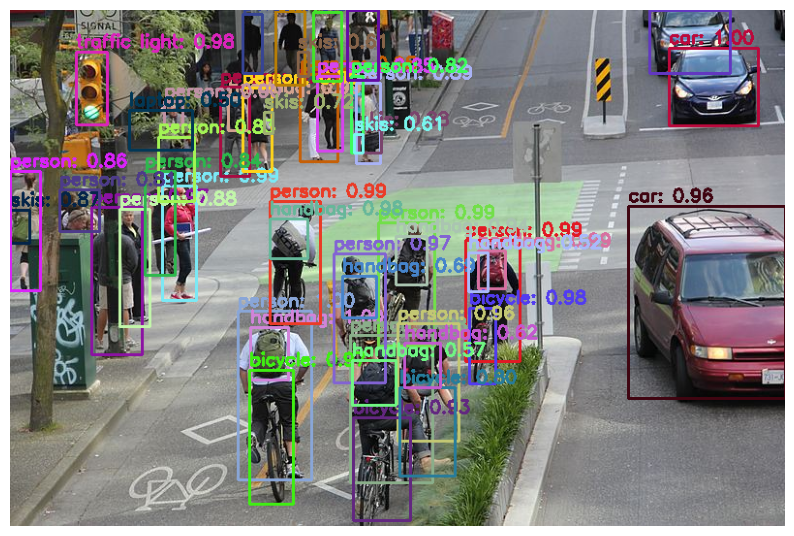

In [8]:
# Display the final image with detected objects and labels
plt.figure(figsize=(10,10))
plt.imshow(output.astype(np.uint8))
plt.axis("off")